In [1]:
#import lilbraries 
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [2]:
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [4]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

# X = input/features
# y = target/output

Features shape: (569, 30)
Labels shape: (569,)


In [5]:
# load data 
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [6]:
print(data.target_names)

['malignant' 'benign']


In [7]:
# Train/ test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# check 
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (455, 30)
Testing: (114, 30)


In [9]:
# feature scaling 

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [10]:
# transform the target variable to a 2D array
scaler.fit_transform(X_train)


array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]], shape=(455, 30))

In [11]:
# scaler.transform(X_test)

# Why?

# Because we must not let the test data influence the training preprocessing.

# This is the same data-leakage principle you should already know from ML.

In [12]:
# build the neural network model

model = Sequential([
    Dense(16, activation="relu", input_shape=(30,)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# model str.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# compile the model 
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
# Optimizer: Adam is a popular optimization algorithm that adjusts the learning rate during training. It combines the benefits of two other extensions of stochastic gradient descent, namely AdaGrad and RMSProp.
optimizer="adam"

In [16]:
# loss 
loss="binary_crossentropy"

In [17]:
# metric 
metrics=["accuracy"]

In [18]:
# train the model 
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6016 - loss: 0.6630 - val_accuracy: 0.7143 - val_loss: 0.5963
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7720 - loss: 0.5216 - val_accuracy: 0.8681 - val_loss: 0.4570
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8599 - loss: 0.4298 - val_accuracy: 0.9011 - val_loss: 0.3742
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9011 - loss: 0.3663 - val_accuracy: 0.9121 - val_loss: 0.3188
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9148 - loss: 0.3164 - val_accuracy: 0.9121 - val_loss: 0.2770
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9258 - loss: 0.2764 - val_accuracy: 0.9341 - val_loss: 0.2458
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9396 - loss: 0.2426 - val_accuracy: 0.9451 - val_loss: 0.2205
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9451 - loss: 0.2159 - val_accuracy: 0.9451 - v

In [19]:
# evaluate the model 
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9649 - loss: 0.1026
Test Loss: 0.10257460922002792
Test Accuracy: 0.9649122953414917


In [20]:
# make predictions
predictions = model.predict(X_test)

print(predictions[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.84996367]
 [0.00464231]
 [0.03430685]
 [0.9652655 ]
 [0.987904  ]]


In [ ]:
# convert the predicted probabilities to class labels (0 or 1) using a threshold of 0.5
predicted_classes = (predictions > 0.5).astype(int)

print(predicted_classes[:10])

[[1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]]


In [22]:
# check the shape of train and test data 
print("Actual:")
print(y_test[:10])

print("Predicted:")
print(predicted_classes[:10].flatten())

Actual:
[1 0 0 1 1 0 0 0 1 1]
Predicted:
[1 0 0 1 1 0 0 0 0 1]


In [25]:
model.fit(X_train, y_train)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9758 - loss: 0.0970 


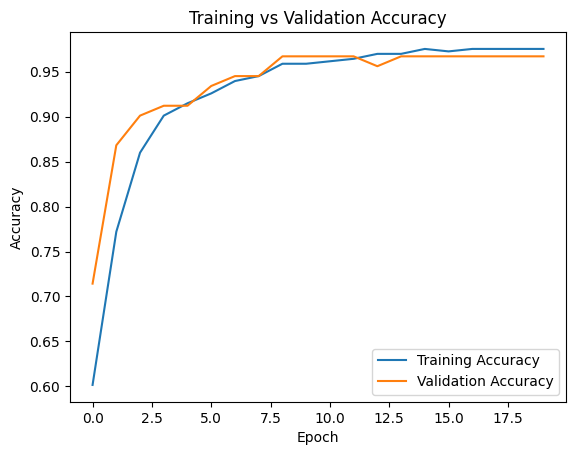

In [23]:
# plotting the progress 
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

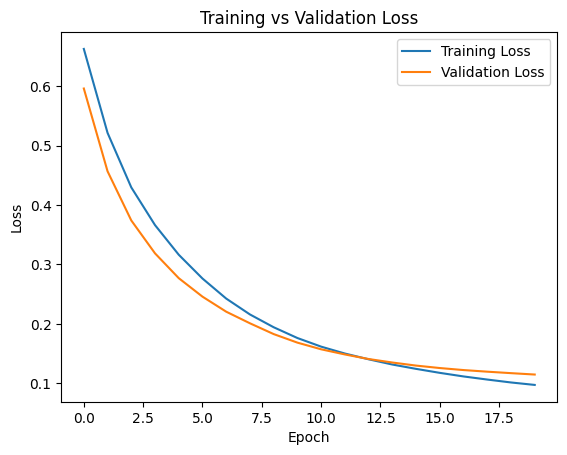

In [24]:
# and loss 
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

             Training

X_train
   ↓
Forward Propagation
   ↓
Prediction
   ↓
Binary Cross Entropy
   ↓
Loss
   ↓
Backpropagation
   ↓
Gradients
   ↓
Adam Optimizer
   ↓
Update Weights
   ↓
Next Batch
   ↓
Repeat